In [29]:
import networkx as nx
import rustworkx as rx
import igraph as ig

import osmnx as ox
import numpy as np

from pathlib import Path

ox.__version__

'2.1.0'

### Initial state

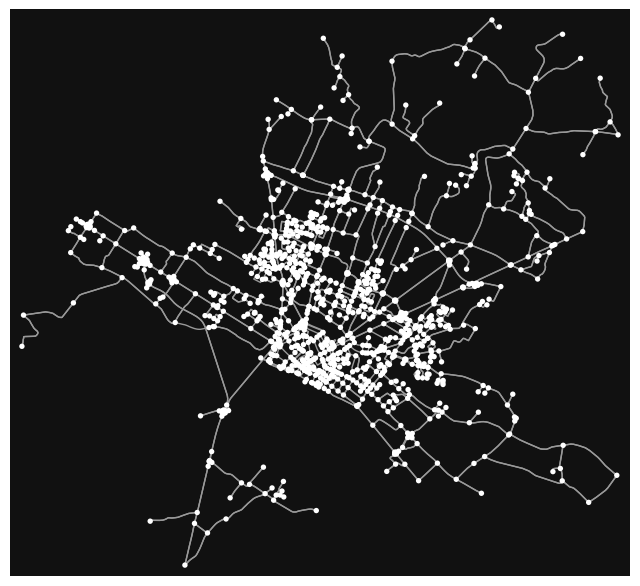

In [30]:
# download/model a street network for some city then visualize it
# G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive") # (edges : 932, nodes : 349)
G = ox.graph.graph_from_place("Marmande, France", network_type="drive") # (edges : 2624, nodes : 1194)
# G = ox.graph.graph_from_place("Pessac, France", network_type="drive") # (edges : 4783, nodes : 2102) CRASH
# G = ox.graph.graph_from_place("Nantes, France", network_type="drive") # (edges : 13848, nodes : 6502) CRASH
fig, ax = ox.plot.plot_graph(G)

In [31]:
G.number_of_edges(), G.number_of_nodes()

(2624, 1194)

### Graph preprocessing

In [32]:
for u,v,k in G.edges:
    attrs_e = {(u, v, k): {
        'demand': 0, 
        'weight': 1, 
        'capacity': np.random.randint(5,10)
        # 'capacity': 1

        }
    }
    nx.set_edge_attributes(G, attrs_e)

for u,v,k in G.edges:
    print(G[u][v][k])
    break

{'osmid': 174792936, 'highway': 'unclassified', 'name': 'Rue Albert Einstein', 'oneway': False, 'reversed': False, 'length': np.float64(161.31819074142834), 'geometry': <LINESTRING (0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 4...>, 'demand': 0, 'weight': 1, 'capacity': 9}


In [33]:
# NX_G=ox.convert.to_digraph(G) NOT FOR NOW CAUSE WE SET WEIGHTS=1 or 10000
NX_G=nx.DiGraph(G)

In [34]:
for u in NX_G.nodes:
    print(NX_G[u])
    break

{1854536498: {'osmid': 174792936, 'highway': 'unclassified', 'name': 'Rue Albert Einstein', 'oneway': False, 'reversed': False, 'length': np.float64(161.31819074142834), 'geometry': <LINESTRING (0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 4...>, 'demand': 0, 'weight': 1, 'capacity': 9}, 1854523734: {'osmid': 174792940, 'highway': 'primary', 'junction': 'roundabout', 'name': 'Rond-Point de la Plaine', 'oneway': True, 'reversed': False, 'length': np.float64(38.03810080669585), 'geometry': <LINESTRING (0.125 44.516, 0.126 44.516, 0.126 44.516, 0.126 44.516, 0.126 4...>, 'demand': 0, 'weight': 1, 'capacity': 6}}


In [35]:
for u,v in NX_G.edges:
    print(NX_G[u][v])
    break

{'osmid': 174792936, 'highway': 'unclassified', 'name': 'Rue Albert Einstein', 'oneway': False, 'reversed': False, 'length': np.float64(161.31819074142834), 'geometry': <LINESTRING (0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 4...>, 'demand': 0, 'weight': 1, 'capacity': 9}


In [36]:
NX_G=NX_G.subgraph(max(nx.strongly_connected_components(NX_G), key=len))

In [37]:
RX_G = rx.networkx_converter(NX_G, keep_attributes=True)

In [38]:
IG_G:ig.Graph = ig.Graph.from_networkx(NX_G)

### Nodes mapping

In [39]:
RX_TO_NX={}
for node_id, node in zip(RX_G.node_indices(), RX_G.nodes()):
    RX_TO_NX[node_id] = node['__networkx_node__']
NX_TO_RX = {v:k for k,v in RX_TO_NX.items()}

NX_TO_RX.items(), RX_TO_NX.items()

(dict_items([(288910186, 0), (288910208, 1), (288910211, 2), (288910215, 3), (288910233, 4), (288915769, 5), (288915777, 6), (288915880, 7), (288915891, 8), (288915902, 9), (288915907, 10), (288915989, 11), (288940259, 12), (288942913, 13), (288942917, 14), (288942920, 15), (299801665, 16), (299801671, 17), (299801677, 18), (299801679, 19), (299801689, 20), (299801690, 21), (299801694, 22), (299801737, 23), (299801741, 24), (299801745, 25), (299801748, 26), (299801749, 27), (299801753, 28), (299801754, 29), (299801755, 30), (299801759, 31), (299801795, 32), (299801796, 33), (299801802, 34), (299801805, 35), (299801807, 36), (301114474, 37), (303030621, 38), (312014388, 39), (312014396, 40), (312014398, 41), (312014432, 42), (312014433, 43), (312014435, 44), (327168838, 45), (327168857, 46), (327168871, 47), (327168887, 48), (327168893, 49), (327168899, 50), (327168906, 51), (327168913, 52), (327168935, 53), (332223554, 54), (332223611, 55), (338928319, 56), (338928323, 57), (338928328,

In [40]:
def map_id(d:dict|int, mapping_dict:dict=NX_TO_RX):
    if type(d)==int:
        return mapping_dict[d]
    elif type(d)==dict:
        return {mapping_dict[k]:[[mapping_dict[node] for node in v]] if v is not None else k for k,v in d.items()}
    elif type(d)==list:
        return {mapping_dict[k]:[[mapping_dict[node] for node in v]] if v is not None else k for k,v in enumerate(d)}


### Time NetworkX

In [41]:
%%time
nx_paths={k:dict(v) for k,v in dict(nx.all_pairs_all_shortest_paths(NX_G)).items()}

CPU times: user 44.3 s, sys: 439 ms, total: 44.8 s
Wall time: 44.8 s


### TESTS RX

In [42]:
(edge_list:=RX_G.edges())[0]

{'osmid': 174792936,
 'highway': 'unclassified',
 'name': 'Rue Albert Einstein',
 'oneway': False,
 'reversed': False,
 'length': np.float64(161.31819074142834),
 'geometry': <LINESTRING (0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 44.516, 0.125 4...>,
 'demand': 0,
 'weight': 1,
 'capacity': 9}

In [43]:
(nodes_list:=RX_G.nodes())[0]

{'y': 44.5160935,
 'x': 0.1254878,
 'street_count': 3,
 '__networkx_node__': 288910186}

In [44]:
RX_G.num_edges(), RX_G.num_nodes()

(2588, 1193)

### Time IGRAPH

In [45]:
%%time
ig_paths={}
nx_ig_paths={}
for node in range(IG_G.vcount()):
    ig_paths[node] = {k:v for k,v in enumerate(IG_G.get_all_shortest_paths(node))}
    # nx_ig_paths[RX_TO_NX[node]] = {RX_TO_NX[k]:[RX_TO_NX[n] for n in v] for k,v in ig_paths.items()}
# nx_ig_paths.items()
# ig_paths

CPU times: user 9.13 s, sys: 1.08 s, total: 10.2 s
Wall time: 10.3 s


### Time RX + conversion, NX

In [ ]:
%%time
RX_G = rx.networkx_converter(NX_G, keep_attributes=True)
rx_paths={k:dict(v) for k,v in dict(rx.all_pairs_dijkstra_shortest_paths(RX_G, edge_cost_fn=lambda x:1)).items()}
# nx_rx_paths={map_id(k, RX_TO_NX): map_id(v, RX_TO_NX) for k,v in rx_paths.items()}
# for node in nx_rx_paths.keys():
#     nx_rx_paths[node][node]=[[node]]
# nx_rx_paths

RX CRASH

In [ ]:
def convert_rustworkx_to_networkx(graph:rx.PyGraph | rx.PyDiGraph):
    """Convert a rustworkx PyGraph or PyDiGraph to a networkx graph."""
    edge_list = [(
        graph[x[0]]['__networkx_node__'], graph[x[1]]['__networkx_node__'],
        {'weight': x[2]}) for x in graph.weighted_edge_list()]
    
    if isinstance(graph, rx.PyGraph):
        if graph.multigraph:
            return nx.MultiGraph(edge_list)
        else:
            return nx.Graph(edge_list)
    else:
        if graph.multigraph:
            return nx.MultiDiGraph(edge_list)
        else:
            return nx.DiGraph(edge_list)

In [ ]:
G6 = convert_rustworkx_to_networkx(RX_G)

In [ ]:
for u,v in G6.edges:
    print(G6[u][v])
    break

{'weight': {'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'demand': 0, 'weight': 1, 'capacity': 6}}


In [ ]:
ox.plot.plot_graph(nx.MultiDiGraph(G6))